# Selective risk under attack

What this shows, in one sentence: **an attack that does not change a single
prediction can still make the abstention rule worse than useless.**

That is the whole reason this harness exists. A deepfake detector in production
does not just classify — it decides what to auto-allow, what to send to a human,
and what to block. Those decisions are driven by the *confidence* attached to a
prediction, not by the prediction itself. So an attacker who cannot flip your
labels can still attack the thing your moderation queue actually reads.

The notebook runs on CPU in about a minute. It trains a small detector on
synthetic data (so it needs no dataset download), then compares three
conditions:

| condition | what it does |
|---|---|
| clean | no perturbation |
| PGD | a prediction attack: destroys accuracy |
| ACE | a confidence attack: leaves accuracy **bit-identical** |

Watch the accuracy column. PGD announces itself there. ACE does not.

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

from trustfake.attacks import ACE, PGD
from trustfake.metrics.evaluation.selective_classification import (
    n_operating_points,
    operating_point_at_coverage,
    rc_curve,
)
from trustfake.metrics.moderation import ModerationPolicy, fit_thresholds
from trustfake.metrics.uncertainty.probs import MultiClassMaxProbability
from trustfake.models.wrapper import BaseWrapper

torch.manual_seed(0)
REAL_CLASS = 0

## A stand-in detector

Two Gaussian blobs per class with heavy overlap, so the model is genuinely
uncertain on part of the data — which is the regime selective classification is
about. A model that is right about everything has nothing to abstain on.

In [2]:
def make_data(n: int, seed: int) -> tuple[torch.Tensor, torch.Tensor]:
    """3 classes (real / synthetic / tampered) with deliberate overlap."""
    g = torch.Generator().manual_seed(seed)
    means = torch.tensor([[0.35, 0.35], [0.55, 0.50], [0.50, 0.62]])
    y = torch.randint(0, 3, (n,), generator=g)
    x = means[y] + 0.11 * torch.randn(n, 2, generator=g)
    # Pad into an image-shaped tensor in [0, 1] so the attacks see what they
    # expect: unnormalised inputs the wrapper normalises internally.
    img = torch.zeros(n, 1, 4, 4)
    img[:, 0, 0, 0] = x[:, 0]
    img[:, 0, 0, 1] = x[:, 1]
    img += 0.02 * torch.rand(n, 1, 4, 4, generator=g)
    return img.clamp(0, 1), y


x_train, y_train = make_data(4000, seed=1)
x_test, y_test = make_data(3000, seed=2)
x_calib, y_calib = make_data(2000, seed=3)

net = nn.Sequential(nn.Flatten(), nn.Linear(16, 64), nn.ReLU(), nn.Linear(64, 3))
model = BaseWrapper(
    normalization_layer=nn.Identity(),
    model=net,
    loss_fn=nn.CrossEntropyLoss(),
    uncertainty_score=MultiClassMaxProbability(),
)

opt = torch.optim.Adam(model.parameters(), lr=0.01)
for epoch in range(400):
    opt.zero_grad()
    nn.functional.cross_entropy(model(x_train)[0], y_train).backward()
    opt.step()

with torch.no_grad():
    print(f"clean test accuracy: {(model(x_test)[2] == y_test).float().mean():.4f}")

clean test accuracy: 0.7293


## The three conditions

`PGD` maximises the loss inside an L∞ ball. `ACE` searches, per sample, for the
largest step that leaves the argmax unchanged — its label preservation is exact
by construction, which is why it returns the logits from its own accept-check
forward rather than letting us re-run the model.

In [3]:
def evaluate(x: torch.Tensor, y: torch.Tensor, logits: torch.Tensor | None = None):
    """Confidence, correctness and p(fake) for one condition."""
    with torch.no_grad():
        if logits is None:
            logits = model(x)[0]
        probs = logits.softmax(dim=1)
    preds = probs.argmax(dim=1)
    return {
        "accuracy": (preds == y).float().mean().item(),
        # The harness ranks by UNCERTAINTY, so low = confident.
        "uncertainty": (1.0 - probs.amax(dim=1)).numpy(),
        "errors": (preds != y).numpy(),
        "p_fake": (1.0 - probs[:, REAL_CLASS]).numpy(),
    }


conditions = {"clean": evaluate(x_test, y_test)}

pgd = PGD(eps=0.05, steps=20)
conditions["PGD (prediction attack)"] = evaluate(pgd(model, x_test, y_test), y_test)

ace_result = ACE(eps=0.05, iters=15).run(model, x_test, y_test)
conditions["ACE (confidence attack)"] = evaluate(
    ace_result.perturbed, y_test, logits=ace_result.accepted_logits
)

## The table

`risk@cov0.5` is the error rate you are left with after abstaining on the half
of the traffic the model is least sure about. It should be *lower* than the
full-coverage error — that is the entire premise of abstention.

`n_op` is the number of distinct confidence operating points. If it collapses
far below the sample count, confidence has saturated into tie blocks and the
AURC beside it is not a precise number. It is printed so a saturated cell is
never read as an exact one.

In [4]:
header = (
    f"{'condition':<26} {'acc':>7} {'AUROC(fail)':>12} "
    f"{'risk@cov1.0':>12} {'risk@cov0.5':>12} {'achieved':>10} {'n_op':>7}"
)
print(header)
print("-" * len(header))

from sklearn.metrics import roc_auc_score

for name, r in conditions.items():
    errors = r["errors"]
    # AUROC of predicting the model's own errors from its uncertainty.
    auroc = (
        roc_auc_score(errors, r["uncertainty"])
        if 0 < errors.sum() < len(errors)
        else float("nan")
    )
    full_risk = errors.mean()
    # The ACHIEVED coverage, never the target: a tie block straddling 0.5
    # means the operating point actually reached can sit well below it.
    achieved, half_risk, _, _ = operating_point_at_coverage(
        r["uncertainty"], errors, 0.5
    )
    n_op = n_operating_points(r["uncertainty"])
    print(
        f"{name:<26} {r['accuracy']:>7.4f} {auroc:>12.4f} "
        f"{full_risk:>12.4f} {half_risk:>12.4f} {achieved:>10.3f} {n_op:>7d}"
    )

condition                      acc  AUROC(fail)  risk@cov1.0  risk@cov0.5   achieved    n_op
--------------------------------------------------------------------------------------------


clean                       0.7293       0.7552       0.2707       0.1133      0.500    2999
PGD (prediction attack)     0.2413       0.6047       0.7587       0.6947      0.500    2997
ACE (confidence attack)     0.7293       0.0049       0.2707       0.5413      0.500    2996


**Read the accuracy column first.** PGD moved it. ACE did not — to four
decimal places it is the clean number, because label preservation is a
constraint of the attack, not a side effect.

Now read `AUROC(fail)` under ACE. Above 0.5 means confidence ranks mistakes
below correct answers, which is what makes abstention work. Below 0.5 means it
ranks them *above*: the model is now most confident exactly where it is wrong.
An abstention rule reading that signal throws away the answers it got right and
keeps the ones it got wrong.

That is why `risk@cov0.5` can end up **higher** than `risk@cov1.0` — abstaining
on half the traffic leaves you worse off than not abstaining at all, which is a
strictly worse system than having no confidence estimate in the first place.

## The risk–coverage curves

Coverage on the x-axis: the fraction of traffic auto-decided. Risk on the
y-axis: the error rate among those decisions. A healthy curve slopes *down* to
the left — abstain more, be wrong less.

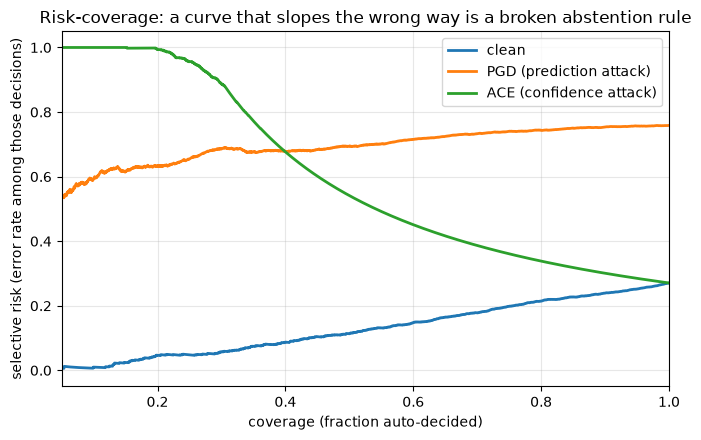

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for name, r in conditions.items():
    coverage, risk, *_ = rc_curve(r["uncertainty"], r["errors"])
    ax.plot(coverage, risk, label=name, linewidth=2)

ax.set_xlabel("coverage (fraction auto-decided)")
ax.set_ylabel("selective risk (error rate among those decisions)")
ax.set_title("Risk-coverage: a curve that slopes the wrong way is a broken abstention rule")
ax.set_xlim(0.05, 1.0)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## What it costs downstream (WP4)

The moderation policy is fitted **once, on clean calibration data**, and then
frozen — which is what a deployment does. It picks two thresholds on `p(fake)`:
below the low one, auto-allow; above the high one, auto-flag; in between, send
to a human.

The SLA is set to 5%, tight enough that meeting it requires a real review
band — at a loose SLA the optimiser correctly answers "review nothing", which
is a valid policy but a dull demonstration.

The number that matters is `residual_risk`: the error rate among the decisions
made *automatically*, with no human in the loop. That is the harm that actually
ships. Note it is measured against the two-threshold decision, not the argmax,
so it need not equal `full-cov err` even at full coverage.

In [6]:
with torch.no_grad():
    calib_probs = model(x_calib)[1]
p_fake_calib = (1.0 - calib_probs[:, REAL_CLASS]).numpy()
y_binary_calib = (y_calib.numpy() != REAL_CLASS).astype(int)

t_low, t_high = fit_thresholds(p_fake_calib, y_binary_calib, sla_residual_risk=0.05)
policy = ModerationPolicy(t_low=t_low, t_high=t_high, real_class=REAL_CLASS)
print(f"policy fitted on clean calib and FROZEN: t_low={t_low:.3f}, t_high={t_high:.3f}\n")

header = f"{'condition':<26} {'coverage':>10} {'review':>10} {'resid.risk':>12} {'full-cov err':>13}"
print(header)
print("-" * len(header))
for name, r in conditions.items():
    probs2 = np.stack([1.0 - r["p_fake"], r["p_fake"]], axis=1)
    out = policy.evaluate(probs2, (y_test.numpy() != REAL_CLASS).astype(int))
    print(
        f"{name:<26} {out['coverage']:>10.4f} {out['review_rate']:>10.4f} "
        f"{out['residual_risk']:>12.4f} {out['full_coverage_error']:>13.4f}"
    )

policy fitted on clean calib and FROZEN: t_low=0.273, t_high=0.733

condition                    coverage     review   resid.risk  full-cov err
---------------------------------------------------------------------------
clean                          0.8633     0.1367       0.0521        0.0950
PGD (prediction attack)        0.9617     0.0383       0.3633        0.3737
ACE (confidence attack)        0.7137     0.2863       0.1383        0.1630


## The point

Read the ACE row across both tables.

**Accuracy is unchanged to four decimal places.** So is the loss, and so is the
confusion matrix. Every monitor a team would normally watch says the detector
is fine.

**Selective risk at 50% coverage doubled** — from 0.113 clean to 0.541 — against
a full-coverage error of 0.271. Abstaining on the half of the traffic the model
is least sure about now leaves you with *twice* the error you would have had by
not abstaining at all. Failure AUROC of 0.005 says why: confidence no longer
ranks mistakes below correct answers, it ranks them above, almost perfectly
inverted.

**The frozen moderation policy degrades on both axes at once.** Residual risk
on auto-decisions goes 0.052 → 0.138 while the review queue doubles, 0.137 →
0.286. The system is simultaneously shipping more harm and demanding more human
time — and the policy has not changed, because it was frozen on clean
calibration data, which is exactly what a deployment does.

Compare that with the PGD row, where the damage is real but *visible*: accuracy
falls from 0.729 to 0.241 and any dashboard catches it in minutes.

That asymmetry is what this harness measures, and what the confidence-axis
defences (`at_conf`, `conf_reg`) are trying to fix. Whether they survive an
*adaptive* attacker — one re-tuned against the defended model — is still open,
and is `TODO.md` §2.

*(Exact numbers depend on the seeds above; the ordering does not.)*

## The attack surface

The demonstrator above used two attacks. The harness carries twenty, and the
taxonomy is data on each attack rather than prose in a table -- because the
distinction that matters here is invisible in a robustness number.

A PREDICTION attack degrades selective risk as a side effect of destroying
accuracy, so an accuracy monitor catches it immediately. A CONFIDENCE attack
degrades selective risk while leaving accuracy bit-identical, so the same
monitor reports a healthy system. Reporting both under one "robustness"
heading is what makes the second one invisible.

`uses_labels` is the other axis worth reading: an attacker holding the ground
truth is a strictly stronger threat model than one who does not, so rows
produced under the two are not comparable.

In [7]:
from trustfake.attacks import attack_registry, describe, ACE, ParamACE

registry = attack_registry()
by_family: dict[str, list[str]] = {}
for meta in registry.values():
    by_family.setdefault(meta["family"], []).append(meta["default_name"])

print(f"{len(registry)} attacks\n")
for family in ("prediction", "confidence", "uncertainty", "evidence"):
    names = sorted(by_family.get(family, []))
    print(f"  {family:12s} ({len(names):2d})  {', '.join(names)}")

labelled = sorted(m["default_name"] for m in registry.values() if m["uses_labels"])
min_norm = sorted(m["default_name"] for m in registry.values() if m["minimum_norm"])
print(f"\n  need ground truth : {', '.join(labelled)}")
print(f"  minimum-norm      : {', '.join(min_norm)}")

20 attacks

  prediction   (14)  a3, apgd, autoattack, bb, bim, cw, deepfool, fab, fgsm, pdpgd, pgd, pgd_l2, square, tr
  confidence   ( 4)  ace, overconf, param_ace_etap1_pred, underconf
  uncertainty  ( 1)  uncertainty_fgsm
  evidence     ( 1)  evidence_pgd

  need ground truth : ace
  minimum-norm      : bb, cw, deepfool, fab, pdpgd


The registry catalogues *classes* at their defaults. For a parameterised
attack the configured instance can differ from the default on exactly the
fields that decide how a row must be read, so a results table should call
`describe()` on the instance it actually ran:

In [8]:
for attack in (ACE(quantize=False), ACE(quantize=True),
               ParamACE(omega="pred"), ParamACE(omega="true")):
    d = describe(attack)
    print(f"  {d['default_name']:22s} uses_labels={str(d['uses_labels']):5s} "
          f"direction={d['direction']}")

  ace                    uses_labels=True  direction=both
  ace_uint8              uses_labels=True  direction=both
  param_ace_etap1_pred   uses_labels=False direction=under_confidence
  param_ace_etap1_true   uses_labels=True  direction=under_confidence


`ace` and `ace_uint8` are the same class under different threat models:
`quantize=True` snaps the perturbation to the 1/255 pixel grid, which is the
attacker who can only upload a *file*. That is the realistic one for a
moderation pipeline, and it must not share a name with the unquantised
variant -- the name keys the log directory, so two conditions sharing one are
one condition run twice.

## Minimum-norm attacks, and why they need a guarantee

The four minimum-norm attacks answer a different question from the
fixed-budget ones: not "does the model survive at eps" but "how little does it
take". That number is what a robustness curve should be read against.

They also have a failure mode with no symptom. If the search stalls, the
attack reports `success=False` -- indistinguishable from a genuinely robust
sample. A fixed-budget attack that breaks the same sample inside the same
radius is a WITNESS that the true minimum norm is at most that radius, so
every such disagreement is a provably overstated robustness number.

This harness guarantees the disagreement cannot happen: each minimum-norm
attack falls back to a bounded search inside its own cap, so it is at least as
strong as a fixed-budget attack at that radius by construction.

In [9]:
from trustfake.attacks import BrendelBethge, CarliniWagner, DeepFool, PDPGD, PGDL2

RADIUS = 0.5
witness = PGDL2(eps=RADIUS, steps=100, use_labels=True)
with torch.enable_grad():
    witness_broke = (model(witness(model, x_test[:256], y_test[:256]))[2]
                     != model(x_test[:256])[2])

print(f"PGD-L2 witness at R={RADIUS} breaks {int(witness_broke.sum())}/256 samples\n")
print(f"  {'attack':10s} {'solved':>7} {'missed a witnessed sample':>27}")
for name, attack in (("deepfool", DeepFool(eps=RADIUS, steps=50)),
                     ("cw",       CarliniWagner(eps=RADIUS, steps=100)),
                     ("bb",       BrendelBethge(eps=RADIUS, steps=100)),
                     ("pdpgd",    PDPGD(eps=RADIUS, steps=100, norm="l2"))):
    with torch.enable_grad():
        result = attack.run(model, x_test[:256], y_test[:256])
    missed = int((witness_broke & ~result.success).sum())
    print(f"  {name:10s} {int(result.success.sum()):>7} {missed:>27}")

print("\nA non-zero last column would be robustness the model does not have.")

PGD-L2 witness at R=0.5 breaks 207/256 samples

  attack      solved   missed a witnessed sample
  deepfool       256                           0


  cw             256                           0


  bb             256                           0
  pdpgd          256                           0

A non-zero last column would be robustness the model does not have.


## Does a defence fix it?

The three defended arms in the harness that target the *label* axis -- PGD-AT,
TRADES, MART -- all assume the adversary wants to change the prediction. The
attack that breaks a moderation layer does not. So the question worth asking
is whether a label-axis defence repairs the confidence axis anyway, or only
looks like it does.

Below is `PGDAdversarialTrainingModule`, the harness's actual PGD-AT pipe,
trained on the same synthetic data and put through the same three
conditions.

In [10]:
from types import SimpleNamespace

from trustfake.pipes.train import PGDAdversarialTrainingModule

torch.manual_seed(0)
defended_net = nn.Sequential(nn.Flatten(), nn.Linear(16, 64), nn.ReLU(), nn.Linear(64, 3))
defended = BaseWrapper(
    normalization_layer=nn.Identity(),
    model=defended_net,
    loss_fn=nn.CrossEntropyLoss(),
    uncertainty_score=MultiClassMaxProbability(),
)
arm = PGDAdversarialTrainingModule(
    model=defended,
    num_classes=3,
    optimizer=torch.optim.Adam(defended.parameters(), lr=0.01),
    eps=0.05,
    steps=7,
)
# The pipe reads `current_epoch` for the eps warm-up; outside a Trainer we
# supply it directly rather than standing up Lightning for a toy model.
arm.trainer = SimpleNamespace(current_epoch=0)
arm.train()

for epoch in range(120):
    arm.optimizer.zero_grad()
    loss, _ = arm.compute_loss([x_train, y_train])
    loss.backward()
    arm.optimizer.step()
arm.eval()
print(f"defended clean accuracy: {(defended(x_test)[2] == y_test).float().mean():.4f}")

defended clean accuracy: 0.7277


In [11]:
from sklearn.metrics import roc_auc_score


def auroc_of_failure(result):
    errors = result["errors"]
    if not 0 < errors.sum() < len(errors):
        return float("nan")
    return roc_auc_score(errors, result["uncertainty"])


def three_conditions(m):
    """Clean / PGD / ACE for a given wrapper, using the harness's attacks."""
    def ev(x, y, logits=None):
        with torch.no_grad():
            probs = (m(x)[0] if logits is None else logits).softmax(dim=1)
        preds = probs.argmax(dim=1)
        return {"accuracy": (preds == y).float().mean().item(),
                "uncertainty": (1.0 - probs.amax(dim=1)).numpy(),
                "errors": (preds != y).numpy()}

    out = {"clean": ev(x_test, y_test)}
    with torch.enable_grad():
        out["PGD"] = ev(PGD(eps=0.05, steps=20)(m, x_test, y_test), y_test)
        ace = ACE(eps=0.05, iters=15).run(m, x_test, y_test)
    out["ACE"] = ev(ace.perturbed, y_test, logits=ace.accepted_logits)
    return out


print(f"{'model':12s} {'condition':10s} {'accuracy':>9} {'AUROC(fail)':>12}")
print("-" * 46)
for label, m in (("undefended", model), ("PGD-AT", defended)):
    for condition, result in three_conditions(m).items():
        print(f"{label:12s} {condition:10s} {result['accuracy']:>9.4f} "
              f"{auroc_of_failure(result):>12.4f}")

model        condition   accuracy  AUROC(fail)
----------------------------------------------
undefended   clean         0.7293       0.7552
undefended   PGD           0.2413       0.6047
undefended   ACE           0.7293       0.0049
PGD-AT       clean         0.7277       0.7494
PGD-AT       PGD           0.6533       0.7131
PGD-AT       ACE           0.7277       0.3596


Read the `ACE` rows against each other. Whatever the defended arm costs on
clean accuracy, the question is whether its failure-AUROC under ACE stays
usable -- above 0.5, where confidence still ranks mistakes below correct
answers -- or inverts like the undefended one.

On the real dataset at eps = 8/255 this is the single most consequential
number in the project: if plain adversarial training repairs the confidence
axis on its own, then the confidence-targeted arms have to beat a defence that
fixes the problem *by accident*, which is a far harder bar than beating an
undefended baseline.

**One caveat this notebook cannot escape:** the defended arm is evaluated
against the same attack family it trained on. A win here is non-adaptive
evidence, which is the weakest kind. The honest version re-tunes the attacker
against the defended model, and that is tracked as open work.

## Working with the real dataset

Everything above runs on synthetic data. SID-Set has a property that makes the
step to real data less obvious than it looks.

### The trap

`width == height -> fake` scores about **0.98** on the raw split. Almost every
fully-synthetic and tampered image is square; most real photographs are not.
That rule is not a model, it reads image dimensions -- so a detector reporting
0.85 accuracy on the raw split is 13 points *below* a rule that ignores the
pixels entirely.

The framework computes that floor for you, and refuses to print a
geometry-controlled headline from uncontrolled numbers.

In [12]:
import os
from pathlib import Path

# The manifest logs its split provenance at INFO on every build. That line is
# load-bearing in a run log -- "test" here is carved from the validation split,
# and a report has to say so -- but it is noise when the same call is made four
# times in one cell.
from trustfake.logging import get_logger

get_logger("manifest").disable("trustfake")

data_dir = Path(os.environ.get("DATA_PATH", "")) / "sid_set"
if not data_dir.exists():
    print(f"  {data_dir} not present -- run jobs/download_sidset.sh to see this live.")
    print("  On the real shards the raw split reports:")
    print("    'width==height -> fake' = 0.9853   majority class = 0.6602")
else:
    from trustfake.data.baselines import compute_trivial_baselines, headline

    raw = compute_trivial_baselines(data_dir, profile="sweep", split_role="test")
    print(headline(raw), "\n")
    for mode in ("square", "nonsquare", "matched"):
        controlled = compute_trivial_baselines(
            data_dir, profile="sweep", split_role="test", geometry_filter=mode
        )
        print(f"  {mode:10s} n={controlled['n']:5d}  "
              f"floor={controlled['square_is_fake']:.4f}  "
              f"majority={controlled['majority_class']:.4f}")

TRIVIAL BASELINE (test, n=3529): 'width==height -> fake' = 0.9853 accuracy (majority class 0.6602). Read every model accuracy against that number. The decode-scale residue 'short side == 1024 -> fake' scores 0.9864 and survives centre-cropping. 



  square     n= 2382  floor=0.9782  majority=0.9782


  nonsquare  n= 1147  floor=1.0000  majority=1.0000


  matched    n=  156  floor=0.6667  majority=0.6667


The `matched` subset equalises the square rate across classes, so geometry
carries no label information and the floor drops to the majority class. A
number from that subset is a claim about *forensic* evidence. A number from
the raw split is not, however good it looks.

### The protocol

Splits are shard-level and firewalled: **fit** from `train-*` shards, **calib**
and **test** from disjoint `validation-*` shards, and the model-selection slice
carved from fit at row level. So early stopping never sees the reported rows,
and post-hoc quantities (a temperature, the moderation thresholds) get their
own split. The assignment is a function of `manifest_seed`, a project constant
deliberately independent of `experiment.seed` -- the reported split must not
move when the training seed does.

Thresholds and temperature are fitted on **clean calib** and then FROZEN
before any attacked condition is scored. Re-fitting on attacked data is an
oracle policy: it assumes the moderator knows an attack is under way, which is
the assumption the attack defeats.

### The ladder

| profile | fit shards | for |
|---|---|---|
| `smoke` | 2 | does the code path run |
| `sweep` | 12 | comparing many configurations, small calib/test |
| `train` | 30 | a reportable single run |
| `all` | every shard on disk | the full-dataset run |
| `all_holdout` | all minus 6, sealed | the same, keeping a holdout back |

Work up it, not down. Sweep numbers **rank**; they do not report -- re-run the
winner at `train` or `all` before quoting anything, or a 20-configuration
search quietly becomes 20 attempts at the reported test split.

```bash
# rank the arms, cheap, on a capped split
python src/sweep.py --strategy ACE --epochs 12 --profile train --subsample 1000

# then the winner, uncapped, for a number worth reporting
python src/train.py experiment.name=final experiment.training_pipe=pgd_at \
    datamodule.datamodule.profile=all adv_eps=0.03137
python src/test.py  experiment.name=final datamodule.datamodule.profile=all
```

Every experiment is pinned at **eps = 8/255** -- Madry's setting and
RobustBench's headline column, so results are comparable to the field rather
than only to each other. Training resumes from `last.ckpt` by default, because
a full-dataset adversarial arm is 13+ hours and an interruption at hour 12
should cost an epoch rather than the run.

### The EV-AT ablation ladder

`src/sweep.py --strategy E` runs evidential adversarial training and the rungs
that decompose it. Each isolates one component:

| arm | isolates |
|---|---|
| `ev_only` | evidential head, **no adversary** |
| `ev_at_b0` | adversary, evidence-alignment off (`beta=0`) |
| `ev_at` | full: adversary + REA |
| `ev_at_awp` | + weight-space perturbation |
| `ev_at_kl`, `ev_at_l2` | same `beta`, different discrepancy |

`pgd_at` is the fourth corner -- adversarial but not evidential. Together they
answer *which part does the work*, rather than only *does it work*, which is
the question an independent harness can ask that a method's own authors
cannot easily ask of their own paper.

## Running the real experiments from here

Everything above is a demonstrator: synthetic data, a toy network, parameters
written inline. It shows the argument; it is not the experiment engine, and it
should not become one. A notebook keeps hidden state, runs cells out of order,
cannot resume a 13-hour arm that died at hour 12, and quietly makes a result
depend on what you happened to execute before it.

So the cells below **drive the real runner** rather than reimplementing it.
Every experiment still goes through `src/sweep.py` and `src/train.py`, with the
same Hydra config capture, the same resume, the same logs -- what you get here
is a control panel and the results read back, not a second code path that can
drift from the first.

Set the knobs, run the launch cell, come back to the results cell.

In [13]:
from __future__ import annotations

import os
import subprocess
import sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# ---- the knobs -----------------------------------------------------------
STRATEGY   = "ACE"   # A=standard/pgd_at/trades  B=at_kl/mart  C=at_conf/conf_reg
                     # E=EV-AT + its ablation ladder. Concatenate: "ACE", "ABCE".
PROFILE    = "train" # smoke | sweep | train | all | all_holdout
EPOCHS     = 12
BATCH      = 32
WORKERS    = 6
SUBSAMPLE  = 1000    # rows every condition is scored on (a prefix of test)
CLEAN_FLOOR = 0.70   # a configuration below this is ranked nowhere
ONLY       = None    # e.g. "ev_at" to run one arm; None runs the whole grid

# Nothing launches unless you flip this. A notebook that starts a multi-hour
# GPU job on "Run All" is a trap, and this one is advertised as a one-minute
# demonstrator -- so the default is to print the command and stop.
LAUNCH = False
# --------------------------------------------------------------------------

cmd = [sys.executable, "src/sweep.py",
       "--strategy", STRATEGY, "--epochs", str(EPOCHS), "--profile", PROFILE,
       "--batch", str(BATCH), "--workers", str(WORKERS),
       "--subsample", str(SUBSAMPLE), "--clean-floor", str(CLEAN_FLOOR)]
if ONLY:
    cmd += ["--only", ONLY]

print("command:\n  " + " ".join(cmd) + "\n")

sys.path.insert(0, str(REPO / "src"))
from sweep import SCORING_CONDITIONS, build_grid  # noqa: E402

grid = build_grid(STRATEGY, EPOCHS)
print(f"{len(grid)} arms x {len(SCORING_CONDITIONS)} conditions "
      f"= {len(grid) * len(SCORING_CONDITIONS)} evaluations")
print("  arms:", ", ".join(c["name"] for c in grid))
print("  conditions:", ", ".join(SCORING_CONDITIONS))

command:
  <repo>/.venv/bin/python src/sweep.py --strategy ACE --epochs 12 --profile train --batch 32 --workers 6 --subsample 1000 --clean-floor 0.7

11 arms x 12 conditions = 132 evaluations
  arms: e8_standard, e8_pgd_at, e8_trades, e8_at_conf, e8_conf_reg, e8_ev_only, e8_ev_at_b0, e8_ev_at, e8_ev_at_awp, e8_ev_at_kl, e8_ev_at_l2
  conditions: clean, pgd, ace_uint8, overconf, underconf, +corruption=jpeg, autoattack, square, deepfool, cw, bb, pdpgd


### Cost, before you commit to it

Measured on one RTX 3090, so scale to your own card. Evaluation is linear in
`SUBSAMPLE`; training is linear in the profile's shard count. Square is
query-bounded rather than convergence-bounded, so it does not get the
early-exit discount the others do and dominates the expensive half.

In [14]:
# measured per-condition seconds at n=1000
CHEAP = {"clean": 45, "pgd": 51, "ace_uint8": 45, "overconf": 54,
         "underconf": 61, "jpeg": 43}
EXPENSIVE = {"autoattack": 140, "square": 592, "deepfool": 167,
             "cw": 165, "bb": 222, "pdpgd": 133}
FIT_IMAGES = {"smoke": 1700, "sweep": 10000, "train": 24054, "all": 210156}
RATE, BF16_SPEEDUP, ADV_COST = 415, 1.7, 8   # img/s fp32; PGD-7 ~8x a step

n_arms = len(grid)
n_adv = sum(1 for c in grid if c["pipe"] not in ("standard", "conf_reg"))
n_cheap_arms = n_arms - n_adv

eval_s = (sum(CHEAP.values()) + sum(EXPENSIVE.values())) * (SUBSAMPLE / 1000) * n_arms
train_s = ((n_cheap_arms + n_adv * ADV_COST)
           * FIT_IMAGES.get(PROFILE, 24054) * EPOCHS / RATE / BF16_SPEEDUP)

print(f"  profile={PROFILE}  subsample={SUBSAMPLE}  arms={n_arms} ({n_adv} adversarial)")
print(f"    training    ~{train_s/3600:6.1f} h")
print(f"    evaluation  ~{eval_s/3600:6.1f} h")
print(f"    TOTAL       ~{(train_s+eval_s)/3600:6.1f} h")
print("\n  Arms with a checkpoint already are skipped, so a re-run that only "
      "adds\n  conditions pays for evaluation alone.")

  profile=train  subsample=1000  arms=11 (8 adversarial)
    training    ~   7.6 h
    evaluation  ~   5.2 h
    TOTAL       ~  12.9 h

  Arms with a checkpoint already are skipped, so a re-run that only adds
  conditions pays for evaluation alone.


In [15]:
if not LAUNCH:
    print("LAUNCH is False -- nothing started.")
    print("Set LAUNCH = True above and re-run this cell, or paste the command "
          "into a terminal.")
else:
    logs = Path(os.environ["LOGS_PATH"]) / f"nb_{STRATEGY}_{PROFILE}_n{SUBSAMPLE}.log"
    logs.parent.mkdir(parents=True, exist_ok=True)
    # Detached, so the run survives this kernel dying -- which is the whole
    # reason not to train inside the notebook process.
    with logs.open("w") as handle:
        proc = subprocess.Popen(cmd, cwd=REPO, stdout=handle,
                                stderr=subprocess.STDOUT, start_new_session=True)
    print(f"launched pid {proc.pid}\n  log: {logs}")
    print("  tail it with:  tail -f " + str(logs))

LAUNCH is False -- nothing started.
Set LAUNCH = True above and re-run this cell, or paste the command into a terminal.


### Reading the results back

`sweep.py` writes every metric through Lightning's CSV logger, so results can
be read at any point -- while the run is still going, or long after it
finished, from a different kernel. This cell does not require the run to have
been started from here.

In [16]:
from sweep import _latest_test_metrics, confidence_resilience  # noqa: E402

header = (f"{'arm':14s} {'clean':>7} {'PGD':>7} {'AutoAtk':>8} {'Square':>7}  "
          f"{'fdAUROC':>8} {'ACE':>7} {'ovconf':>7} {'resil':>7}")
print(header)
print("-" * len(header))

def fmt(v):
    return f"{v:.4f}" if isinstance(v, float) else "   -   "

for cfg in grid:
    m = _latest_test_metrics(cfg["name"])
    if not m or "nat_accuracy_top1" not in m:
        print(f"{cfg['name']:14s}  (not finished)")
        continue
    resilience = confidence_resilience(m)
    print(f"{cfg['name']:14s} {fmt(m.get('nat_accuracy_top1')):>7} "
          f"{fmt(m.get('pgd_accuracy_top1')):>7} "
          f"{fmt(m.get('autoattack_accuracy_top1')):>8} "
          f"{fmt(m.get('square_accuracy_top1')):>7}  "
          f"{fmt(m.get('nat_fd_auroc')):>8} {fmt(m.get('ace_uint8_fd_auroc')):>7} "
          f"{fmt(m.get('overconf_fd_auroc')):>7} "
          f"{fmt(resilience) if resilience is not None else '   -   ':>7}")

print("\n  resil = mean failure-AUROC under ace_uint8 and overconf -- the "
      "ranking\n  objective. Above 0.5 confidence still ranks mistakes below "
      "correct answers.")

arm              clean     PGD  AutoAtk  Square   fdAUROC     ACE  ovconf   resil
---------------------------------------------------------------------------------
e8_standard     0.8250  0.1600   0.0000  0.0160    0.8428  0.1335  0.5726  0.3530
e8_pgd_at       0.7070  0.6810     -       -       0.7398  0.7170  0.7283  0.7226
e8_trades       0.7210  0.6950     -       -       0.7787  0.7451  0.7751  0.7601
e8_at_conf      0.7790  0.2760     -       -       0.7731  0.6053  0.8091  0.7072
e8_conf_reg     (not finished)
e8_ev_only      (not finished)
e8_ev_at_b0     (not finished)
e8_ev_at        (not finished)
e8_ev_at_awp    (not finished)
e8_ev_at_kl     (not finished)
e8_ev_at_l2     (not finished)

  resil = mean failure-AUROC under ace_uint8 and overconf -- the ranking
  objective. Above 0.5 confidence still ranks mistakes below correct answers.


### What this notebook still will not do

- **Report numbers.** A capped `SUBSAMPLE` ranks configurations; it does not
  produce a quotable result. Re-run the winner uncapped at `--profile all`.
- **Replace the CLI for a long run.** The launch cell detaches deliberately,
  but a 60-hour full-dataset sweep belongs in a terminal or a systemd unit
  where you are not one closed laptop away from losing the shell.
- **Decide anything about seeds.** Every arm here is one seed. Close arms will
  not separate, and reading an ordering off single runs reads noise.